# Dsa Source Iteration 1D

**Purpose.** Reproduce the named radiative-transfer experiment with its original computational workflow.

**Distinction.** This notebook is the canonical study; existing code, parameters, outputs, and execution order are unchanged.


In [1]:
from matplotlib.ticker import LinearLocator
import numpy as np
import matplotlib.pyplot as plt
from jax import vmap
import sys
import jax

jax.config.update("jax_platform_name", "cpu")


sys.path.append("..")

In [2]:
from configuration.rte_1d_settings import get_config

rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
kn = 5e-1  # rte_config.model.knudsen_number
num_quads = rte_config.model.num_quads
fn_sigma_s = rte_config.model.coeff["scattering"]
fn_sigma_a = rte_config.model.coeff["absorption"]


def fn_source(x, v):
    return np.zeros_like(v)


# def fn_source(x, v):
#     return -v / kn


fn_l = rte_config.model.bdy_cond["f_l"]
fn_r = rte_config.model.bdy_cond["f_r"]
num_x, num_v = (
    rte_config.model.grid_sizes
)  # num_v % 2 == 0 such that v = 0 is not included
print(f"num_x = {num_x}, num_v = {num_v}")

num_x = 1024, num_v = 2048


In [3]:
(xmin, xmax), (vmin, vmax) = domain["x"], domain["v"]
dx = (xmax - xmin) / num_x
kn_dx = kn / dx
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin + dx / 2, xmax - dx / 2, num_x
)  # num_x pts in cell center (not include gohst points)
# x, xc
# quadratures = leggauss(num_v)
# mesh_v, weights = quadratures
# mesh_v = mesh_v.squeeze()
mesh_v = np.linspace(vmin, vmax, num_v)  # num_v % 2 == 0
# h = (vmax - vmin) / (num_v - 1)
# w = np.ones((num_v,))
# w[0], w[-1] = 0.5, 0.5
# weights = h * w
weights = np.ones((num_v,)) * (vmax - vmin) / (num_v - 1)
v_pos = mesh_v[mesh_v > 0]
v_neg = mesh_v[mesh_v < 0]
vector_sigma_s = np.asarray(vmap(fn_sigma_s)(mesh_xc))[:, None]  # (num_x, 1)
vector_sigma_a = np.asarray(vmap(fn_sigma_a)(mesh_x))[
    :, None]  # (num_x - 1, 1)
vector_sigma_t = np.asarray(
    vmap(fn_sigma_s)(mesh_xc)[:, None] + kn**2 *
    vmap(fn_sigma_a)(mesh_xc)[:, None]
)  # (num_x, 1)

In [4]:
# vector_source = np.asarray(vmap(fn_source)(mesh_xc))[:, None]
X, V = np.meshgrid(mesh_xc, mesh_v, indexing="ij")  # shape = (num_x, num_v)
vector_source = fn_source(X, V)  # shape = (num_x, num_v)

matrix_f = np.ones((num_x + 1, num_v))
matrix_fc = np.zeros((num_x, num_v))
matrix_f[0, mesh_v > 0] = np.asarray(vmap(fn_l)(v_pos))
matrix_f[-1, mesh_v < 0] = np.asarray(vmap(fn_r)(v_neg))

diag1 = -1.0 / vector_sigma_s[1:-1].flatten() / 3.0
diag0 = (
    (vector_sigma_s[1:] + vector_sigma_s[:-1])
    / (vector_sigma_s[1:] * vector_sigma_s[:-1])
    / 3.0
    + vector_sigma_a[1:-1] * dx**2
).flatten()
tri_diag = np.diag(diag0) + np.diag(diag1, -1) + np.diag(diag1, 1)

In [5]:
def compute_q(matrix_f, weights, vector_sigma_s, vector_source, kn):
    matrix_fc = 0.5 * (matrix_f[1:] + matrix_f[:-1])  # shape (num_x, num_v)
    avg = 0.5 * matrix_fc @ weights[:, None]  # shape (num_x, 1)
    q = vector_sigma_s * avg + kn**2 * vector_source  # shape (num_x, num_v)
    return q, avg

In [6]:
def SA_source_iteration(matrix_f):
    # step 1: transport sweep
    F = matrix_f.copy()
    q, rho = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(-1, -num_x - 1, -1):
        # F[i - 1, mesh_v < 0] = (
        #     q[i] / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
        #     - (0.5 * vector_sigma_t[i, 0] + kn_dx * v_neg)
        #     / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
        #     * F[i, mesh_v < 0]
        # )
        F[i - 1, mesh_v < 0] = (
            q[i, mesh_v < 0] / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            - (0.5 * vector_sigma_t[i, 0] + kn_dx * v_neg)
            / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            * F[i, mesh_v < 0]
        )

    q, rho = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(num_x):
        # F[i + 1, mesh_v > 0] = (
        #     q[i] / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
        #     - (0.5 * vector_sigma_t[i, 0] - kn_dx * v_pos)
        #     / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
        #     * F[i, mesh_v > 0]
        # )
        F[i + 1, mesh_v > 0] = (
            q[i, mesh_v > 0] / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            - (0.5 * vector_sigma_t[i, 0] - kn_dx * v_pos)
            / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            * F[i, mesh_v > 0]
        )

    # step 2: correction
    delta_F = np.zeros((num_x + 1, 1))
    source_current = (
        0.5 * (F - matrix_f)[1:-1, :] @ weights[:, None] * (dx / kn) ** 2
    )  # shape (num_x - 1, 1)
    delta_F[1:-1, :] = np.linalg.inv(tri_diag) @ source_current
    F_updated = F + delta_F
    return F_updated

In [7]:
def dvm_solver(
    matrix_f: np.array, tol: float = 1e-12, max_iter: int = 2**12
) -> np.array:
    for i in range(max_iter):
        matrix_f_new = SA_source_iteration(matrix_f)
        diff = np.linalg.norm(matrix_f_new - matrix_f)
        print(f"difference = {diff:.4e}")
        if diff < tol:
            print(f"converged at iter {i}")
            break
        matrix_f = matrix_f_new
    return matrix_f

In [ ]:
import time

start_time = time.time()
matrix_f = dvm_solver(matrix_f)
end_time = time.time()
print(f"Total time: {end_time - start_time:.2f} seconds")

difference = 5.0607e+02


In [ ]:
X, V = np.meshgrid(mesh_x[1:-1], mesh_v[1:-1])
F = matrix_f.T[1:-1, 1:-1]

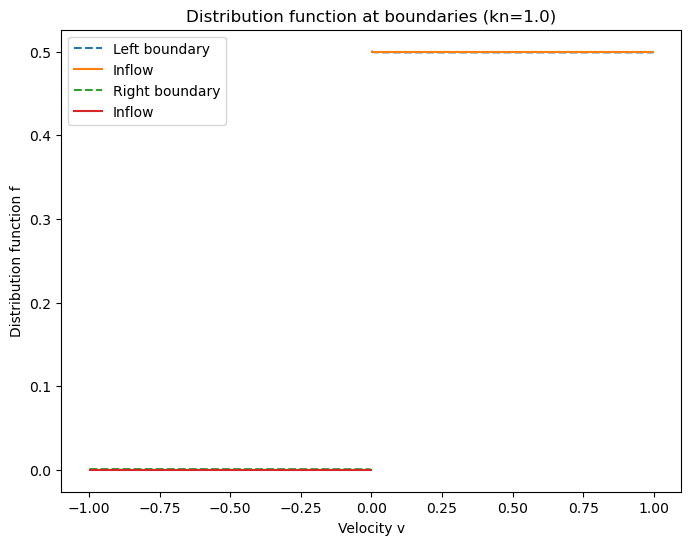

In [ ]:
Fl = F[mesh_v[1:-1] > 0, 0]
fl = np.ones_like(Fl) / 2
Vl = mesh_v[1:-1][mesh_v[1:-1] > 0]
Fr = F[mesh_v[1:-1] < 0, -1]
fr = np.zeros_like(Fr)
Vr = mesh_v[1:-1][mesh_v[1:-1] < 0]
fig = plt.figure(figsize=(8, 6))
ax = plt.plot(Vl, Fl, "--", label="Left boundary")
ax = plt.plot(Vl, fl, "-", label="Inflow")
ax = plt.plot(Vr, Fr, "--", label="Right boundary")
ax = plt.plot(Vr, fr, "-", label="Inflow")
ax = plt.xlabel("Velocity v")
ax = plt.ylabel("Distribution function f")
ax = plt.title(f"Distribution function at boundaries (kn={kn})")
ax = plt.legend()

findfont: 

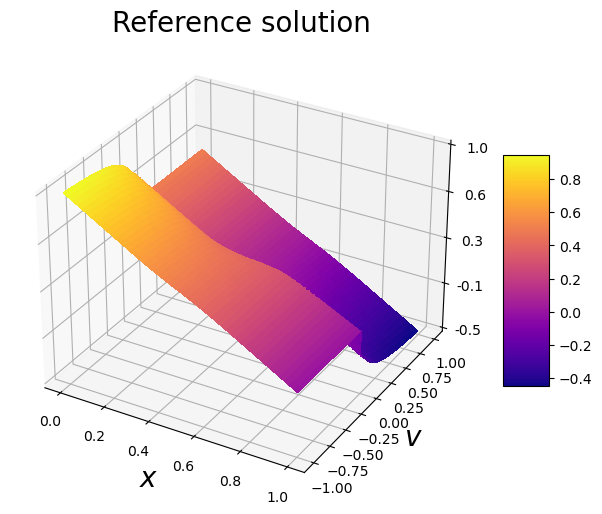

In [ ]:
font_format = {"size": 20}

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F, cmap="plasma",
                         linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.show()

findfont: 

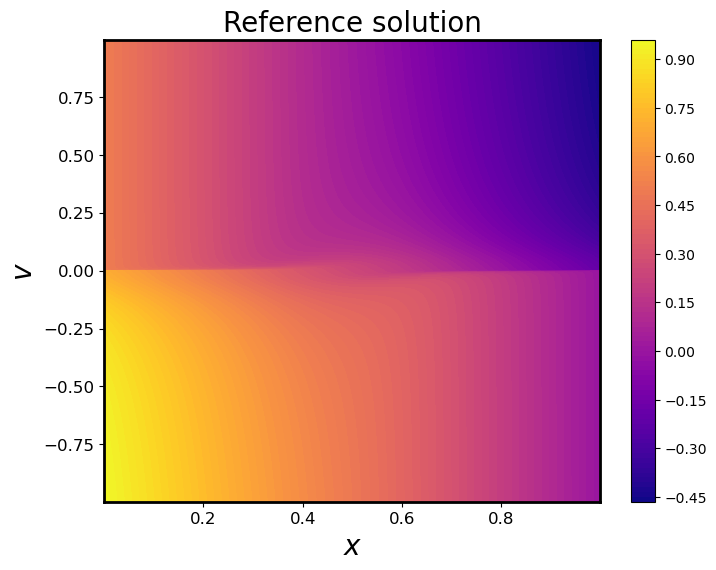

In [ ]:
font_format = {"size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

In [ ]:
# np.savez(
#     f"../data/rte1d_ex1_ref_{kn:.1e}.npz",
#     mesh_x=mesh_x[1:-1],
#     mesh_v=mesh_v[1:-1],
#     F=F,
# )
# print(f"kn = {kn:.2e}, data saved.")

In [ ]:
# f = 1.0 - X
# E = F - f

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # --- 数值解 ---
# cs0 = axes[0].contourf(X, V, F, 100, cmap="plasma")
# axes[0].set_title("Numerical solution", font_format)
# axes[0].set_xlabel(r"$x$", font_format)
# axes[0].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs0, ax=axes[0])

# # --- 精确解 ---
# cs1 = axes[1].contourf(X, V, f, 100, cmap="plasma")
# axes[1].set_title("Exact solution", font_format)
# axes[1].set_xlabel(r"$x$", font_format)
# axes[1].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs1, ax=axes[1])

# # --- 误差 ---
# cs2 = axes[2].contourf(X, V, E, 100, cmap="coolwarm")
# axes[2].set_title("Error", font_format)
# axes[2].set_xlabel(r"$x$", font_format)
# axes[2].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs2, ax=axes[2])

# plt.tight_layout()
# plt.show()

In [ ]:
# rel_L2 = np.linalg.norm(E) / np.linalg.norm(f)
# linf = np.max(np.abs(E))

# print(f"relative L2 error = {rel_L2:.3e},  Linf = {linf:.3e}")

In [ ]:
np.savez(
    f"../data/rte1d_ex2_ex_{kn:.1e}.npz",
    mesh_x=mesh_x[1:-1],
    mesh_v=mesh_v[1:-1],
    F=F,
)